# MFAA Chapter 12 Laboratory
**Real Asset Cash-Flow Engine** (book §12.9)

Value layered real-asset claims: lease ladders on market-rent dynamics, regime cap rates, development options. 'Slow numerator, fast denominator.' Seed `20261200`.

In [1]:
import sys, numpy as np, matplotlib.pyplot as plt
sys.path.insert(0,'..')
from engine import ch12
from dataclasses import replace

## 1. E1 / Ex 12.10 — Slow numerator, fast denominator (Proposition 12.4)
The rent roll low-passes market rent; g(κℓ) drops from **0.5677** (ℓ=5) to **0.3773** (ℓ=10).

lease term 5.0y: low-pass ratio g(kappa*ell) = 0.5677
lease term 10.0y: low-pass ratio g(kappa*ell) = 0.3773


Text(0.5, 0, 'years')

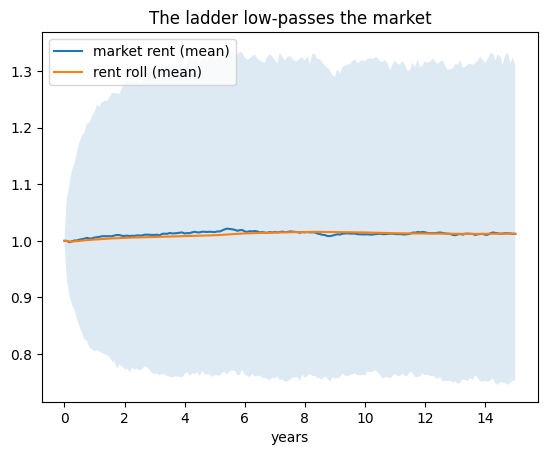

In [2]:
for ell in (5.0, 10.0):
    print(f"lease term {ell}y: low-pass ratio g(kappa*ell) = {ch12.lowpass_ratio(0.4, ell):.4f}")
sim = ch12.rent_roll_simulation(ch12.RealAssetParams(M=2000))
t = sim['tgrid']
plt.plot(t, sim['market_rent'].mean(axis=1), label='market rent (mean)')
plt.plot(t, sim['rent_roll'].mean(axis=1), label='rent roll (mean)')
plt.fill_between(t, np.quantile(sim['market_rent'],.05,axis=1), np.quantile(sim['market_rent'],.95,axis=1), alpha=.15)
plt.legend(); plt.title('The ladder low-passes the market'); plt.xlabel('years')

## 2. The value fan under regime cap rates
Value volatility is dominated by the fast-moving denominator.

variance share: numerator 0.35, denominator 0.65


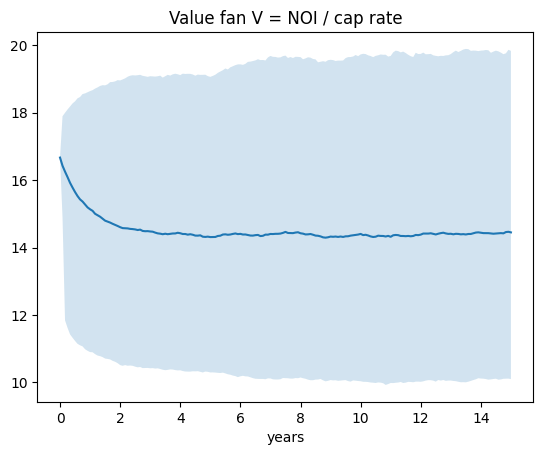

In [3]:
vf = ch12.value_fan(ch12.RealAssetParams(M=4000))
t = vf['tgrid']
plt.plot(t, vf['value'].mean(axis=1), 'C0-')
plt.fill_between(t, np.quantile(vf['value'],.05,axis=1), np.quantile(vf['value'],.95,axis=1), alpha=.2)
plt.title('Value fan V = NOI / cap rate'); plt.xlabel('years')
print(f"variance share: numerator {vf['numerator_var_share']:.2f}, denominator {vf['denominator_var_share']:.2f}")

## 3. Ex 12.12 — The development option (Proposition 12.6)
β=1.406, V*=3.46K at σ=0.25, ρ=6%, μ=3%. The NPV rule builds too early.

In [4]:
do = ch12.development_option(ch12.RealAssetParams(dev_sigma=0.25, dev_rho=0.06, dev_mu=0.03), V=1.2)
print(f"beta = {do['beta']:.3f}, V* = {do['V_star_over_K']:.2f}K")
print(f"land value at V=1.2K: {do['land_value_over_K']:.3f}K (optimal), NPV rule: {do['npv_rule_value']:.3f}K")
print(f"value lost by NPV rule: {do['value_lost_fraction']*100:.0f}%")

beta = 1.406, V* = 3.46K
land value at V=1.2K: 0.555K (optimal), NPV rule: 0.200K
value lost by NPV rule: 64%


## 4. Validation checks

In [5]:
v = ch12.validation_checks()
for k,d in v.items():
    if isinstance(d,dict): print(k, 'PASS' if d['pass_'] else 'FAIL')
print('ALL:', v['all_pass'])

V1_lowpass PASS
V2_development PASS
V3_development_mc PASS
V4_lowpass_monotone PASS
V5_hurdle_in_sigma PASS
V6_reproducible PASS
ALL: True
